In [1]:
import numpy as np
from pathlib import Path
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

# Sabitler
TARGET_LEN = 4096   # Her EEG sinyalinin uzunluğu
DATA_PATH = "C:/Users/Mehmet Ersolak/Desktop/EEG_Epilepsi_Proje/BTK PROJE(EEG)"  # Buraya kendi veri klasör yolunu yaz


In [2]:
# 1D sinyalleri yükleme
def load_txt_signal(path):
    x = np.loadtxt(path, dtype=float)
    if x.ndim > 1:
        x = x.squeeze()
    return x

def pad_or_crop(x, L=TARGET_LEN):
    if len(x) > L:
        start = (len(x)-L)//2
        return x[start:start+L]
    elif len(x) < L:
        pad = L - len(x)
        return np.pad(x, (0,pad), mode="constant")
    return x

def zscore(x):
    return (x - np.mean(x)) / (np.std(x)+1e-8)

def preprocess_file(path):
    x = load_txt_signal(path)
    x = pad_or_crop(x, TARGET_LEN)
    x = zscore(x)
    return x.astype(np.float32)

def load_dataset(root=DATA_PATH):
    # N sınıfı eklendi
    classes = ["F","N","O","S","Z"]
    X, y = [], []
    root_path = Path(root)
    for cls in classes:
        class_path = root_path / cls
        if not class_path.exists():
            print(f"⚠️ {cls} klasörü bulunamadı: {class_path}")
            continue
        for p in class_path.glob("*.txt"):
            X.append(preprocess_file(p))
            y.append(classes.index(cls))
    if len(X) == 0:
        print("⚠️ Hiç dosya bulunamadı. Lütfen klasör ve dosya yapısını kontrol edin.")
    X = np.expand_dims(np.array(X), -1) if X else np.zeros((0, TARGET_LEN, 1))
    y = np.array(y) if y else np.zeros((0,))
    return X, y, classes

# Veri yükleme
X, y, classes = load_dataset(DATA_PATH)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Sınıflar:", classes)
if len(y) > 0:
    unique, counts = np.unique(y, return_counts=True)
    class_dist = {classes[i]: counts[i] for i in range(len(unique))}
    print("Sınıf dağılımı:", class_dist)

X shape: (500, 4096, 1)
y shape: (500,)
Sınıflar: ['F', 'N', 'O', 'S', 'Z']
Sınıf dağılımı: {'F': np.int64(100), 'N': np.int64(100), 'O': np.int64(100), 'S': np.int64(100), 'Z': np.int64(100)}


In [3]:
from sklearn.model_selection import train_test_split

# %80 eğitim, %20 doğrulama
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Eğitim seti:", X_train.shape, y_train.shape)
print("Doğrulama seti:", X_val.shape, y_val.shape)


Eğitim seti: (400, 4096, 1) (400,)
Doğrulama seti: (100, 4096, 1) (100,)


In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_model(input_len=4096, n_classes=5):
    input_layer = layers.Input(shape=(input_len,1))
    
    x = layers.Conv1D(32, 11, padding="same")(input_layer)
    x = layers.LeakyReLU(alpha = 0.3)(x)
    
    x = layers.MaxPooling1D(4)(x)
    x = layers.Conv1D(64, 9, padding="same")(x)
    x = layers.LeakyReLU(alpha = 0.3)(x)
    
    x = layers.MaxPooling1D(4)(x)
    x = layers.Conv1D(128, 7, padding="same")(x)
    x = layers.LeakyReLU(alpha = 0.3)(x)
    
    x = layers.GlobalAveragePooling1D()(x)
    
    x = layers.Dense(64, activation="relu")(x)
    out = layers.Dense(n_classes, activation="softmax")(x)

    model = models.Model(input_layer, out)
    model.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model

model = build_model()
model.summary()


C:\Users\Mehmet Ersolak\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 4096, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 4096, 32)       │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 4096, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 1024, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 1024, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 1024, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 256, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 256, 128)       │        57,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 256, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,933 (331.77 KB)

 Trainable params: 84,933 (331.77 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("models/best_model.keras", save_best_only=True)
]
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6)

In [6]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, X_test, y_test, class_names=None):
    # Tahminleri al
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)
    
    # Classification Report (Precision, Recall, F1)
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred_classes, digits=4, target_names=class_names))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_classes)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 414ms/step - accuracy: 0.2075 - loss: 1.6002 - val_accuracy: 0.3100 - val_loss: 1.5422 - learning_rate: 0.0010
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 321ms/step - accuracy: 0.3425 - loss: 1.5193 - val_accuracy: 0.3300 - val_loss: 1.4151 - learning_rate: 0.0010
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 326ms/step - accuracy: 0.3600 - loss: 1.3437 - val_accuracy: 0.4700 - val_loss: 1.1920 - learning_rate: 0.0010
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 319ms/step - accuracy: 0.5250 - loss: 1.1087 - val_accuracy: 0.5600 - val_loss: 0.9557 - learning_rate: 0.0010
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 316ms/step - accuracy: 0.6400 - loss: 0.8694 - val_accuracy: 0.6600 - val_loss: 0.7865 - learning_rate: 0.0010
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 319ms/step - accuracy: 0.6775 - loss: 0.7576 - val_accuracy: 0.6700 - val_loss: 0.7016 - learning_rate: 0.0010
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 320ms/step - accuracy: 0.6875 - loss: 0.6951 - val_acc

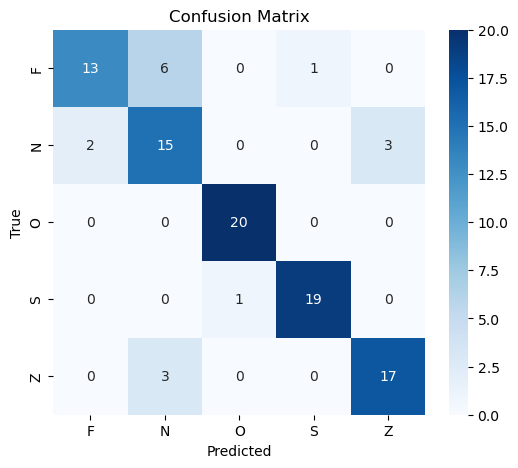

In [7]:
# Eğitim
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    callbacks=[callbacks, reduce_lr]
)

# Test metrikleri
class_names = ["F", "N", "O", "S", "Z"]  # kendi sınıflarını buraya yaz
evaluate_model(model, X_val, y_val, class_names)

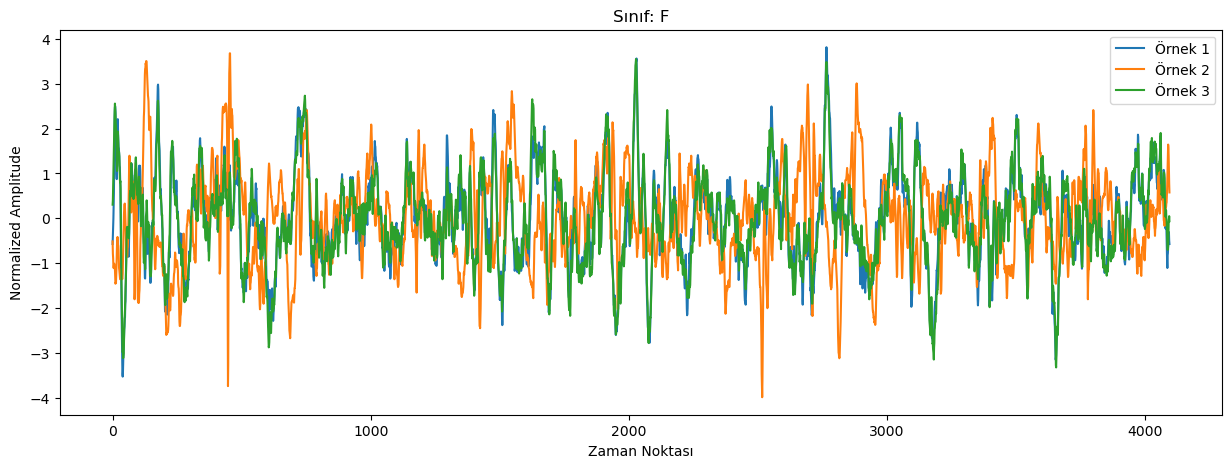

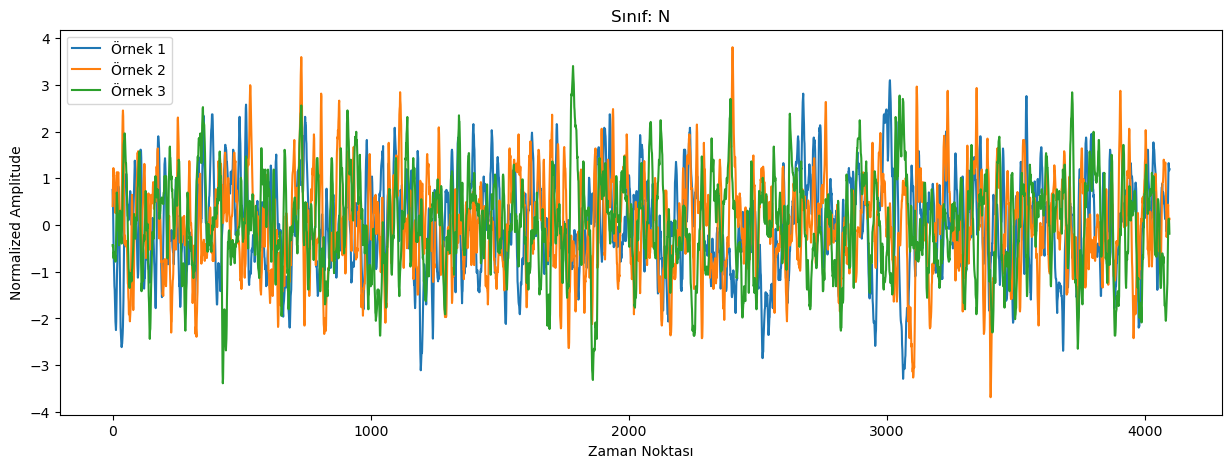

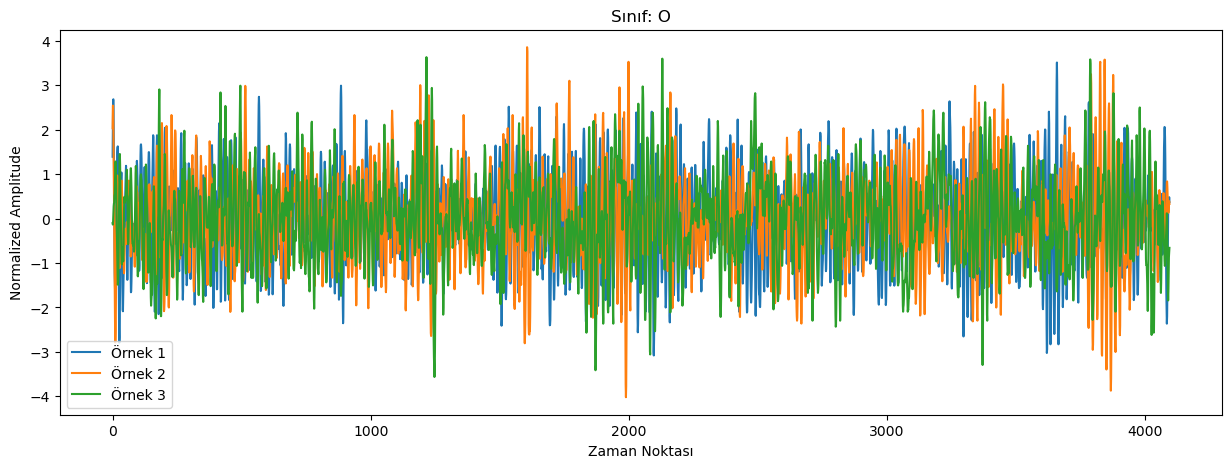

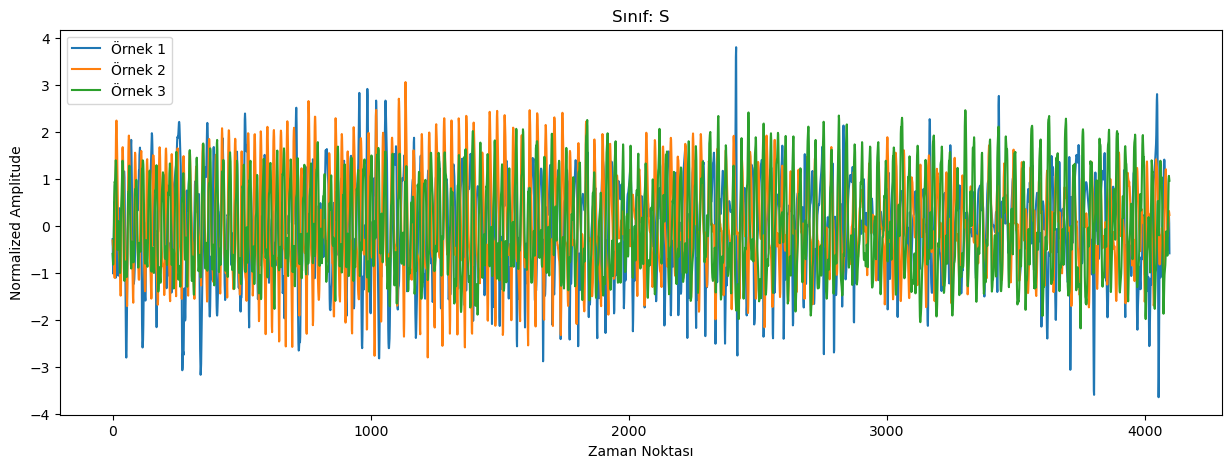

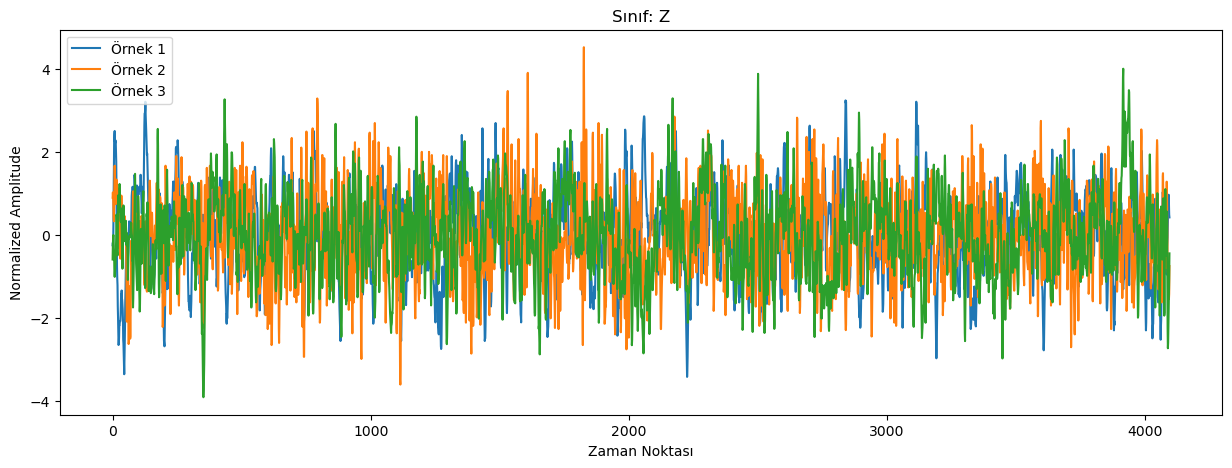

In [23]:
import matplotlib.pyplot as plt
import random

def plot_random_signals(X, y, classes, n_per_class=3):
    for cls_idx, cls_name in enumerate(classes):
        idxs = np.where(y==cls_idx)[0]
        chosen = random.sample(list(idxs), min(n_per_class, len(idxs)))
        plt.figure(figsize=(15, 5))
        for i, idx in enumerate(chosen):
            plt.plot(X[idx].squeeze(), label=f"Örnek {i+1}")
        plt.title(f"Sınıf: {cls_name}")
        plt.xlabel("Zaman Noktası")
        plt.ylabel("Normalized Amplitude")
        plt.legend()
        plt.show()

plot_random_signals(X, y, classes)


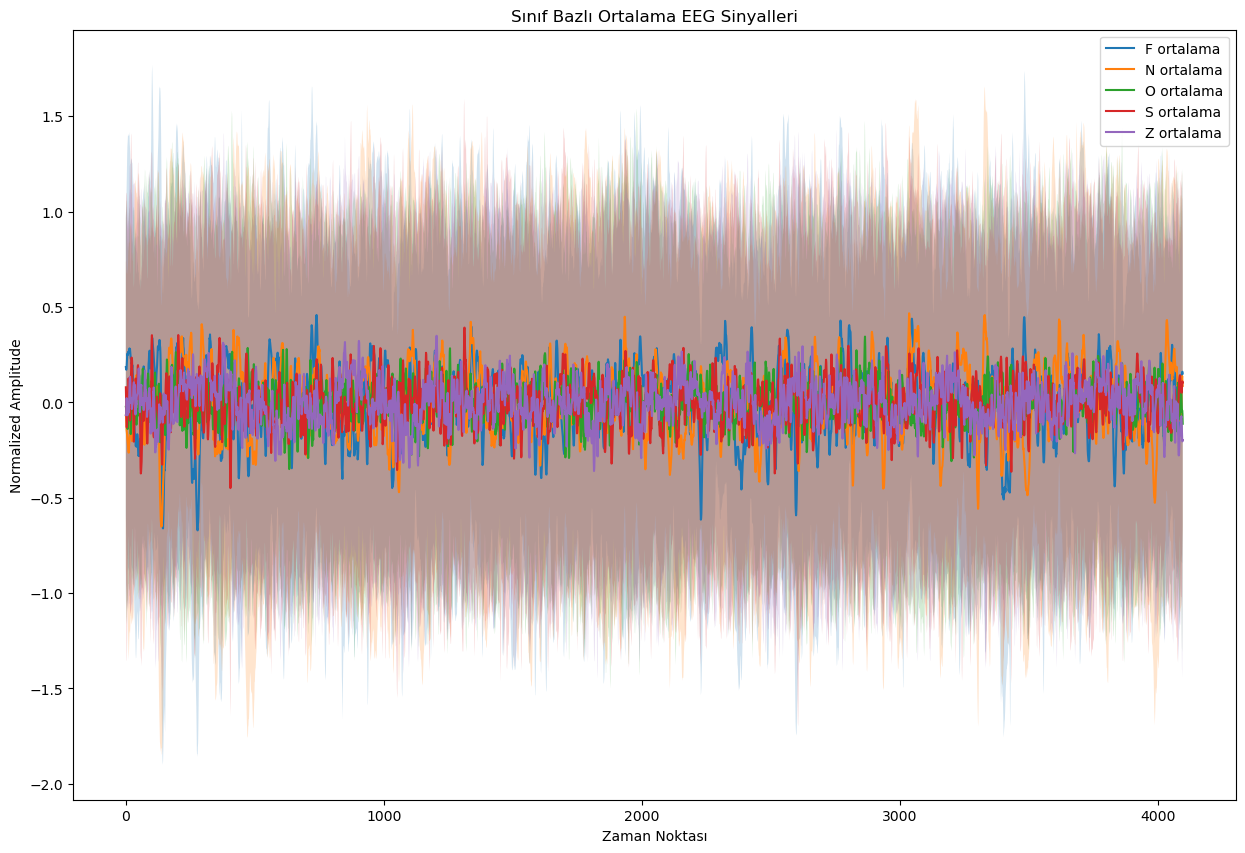

In [9]:
def plot_class_average(X, y, classes):
    plt.figure(figsize=(15, 10))
    for cls_idx, cls_name in enumerate(classes):
        signals = X[y==cls_idx].squeeze()
        if len(signals) == 0:
            continue
        mean_signal = np.mean(signals, axis=0)
        std_signal = np.std(signals, axis=0)
        plt.plot(mean_signal, label=f"{cls_name} ortalama")
        plt.fill_between(range(len(mean_signal)), mean_signal-std_signal, mean_signal+std_signal, alpha=0.2)
    plt.title("Sınıf Bazlı Ortalama EEG Sinyalleri")
    plt.xlabel("Zaman Noktası")
    plt.ylabel("Normalized Amplitude")
    plt.legend()
    plt.show()

plot_class_average(X, y, classes)


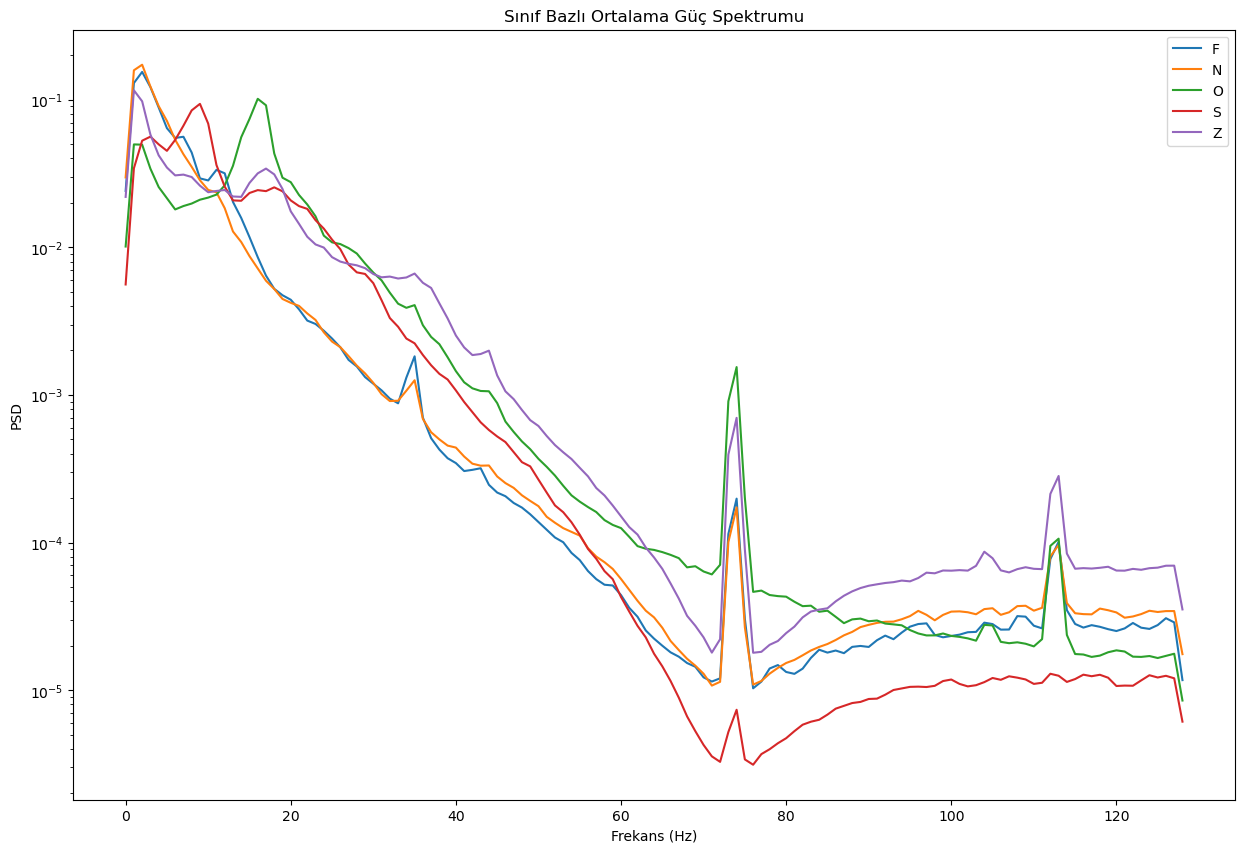

In [10]:
from scipy.signal import welch

def plot_class_psd(X, y, classes, fs=256):
    plt.figure(figsize=(15, 10))
    for cls_idx, cls_name in enumerate(classes):
        signals = X[y==cls_idx].squeeze()
        if len(signals) == 0:
            continue
        psd_list = []
        for sig in signals:
            f, Pxx = welch(sig, fs=fs)
            psd_list.append(Pxx)
        mean_psd = np.mean(psd_list, axis=0)
        plt.semilogy(f, mean_psd, label=f"{cls_name}")
    plt.title("Sınıf Bazlı Ortalama Güç Spektrumu")
    plt.xlabel("Frekans (Hz)")
    plt.ylabel("PSD")
    plt.legend()
    plt.show()

plot_class_psd(X, y, classes)


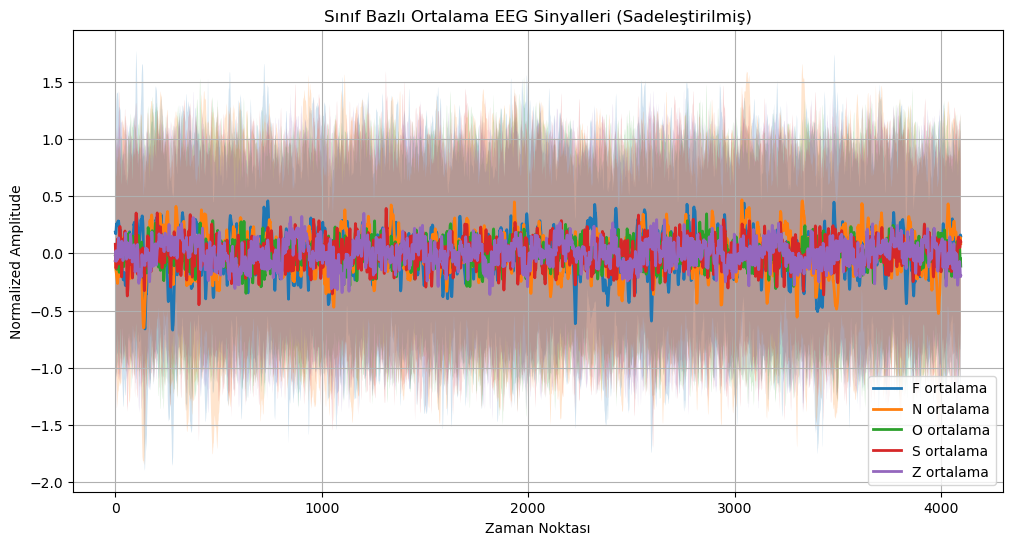

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def plot_class_average_simple(X, y, classes):
    plt.figure(figsize=(12, 6))
    for cls_idx, cls_name in enumerate(classes):
        signals = X[y==cls_idx].squeeze()
        if len(signals) == 0:
            continue
        mean_signal = np.mean(signals, axis=0)
        std_signal = np.std(signals, axis=0)
        plt.plot(mean_signal, label=f"{cls_name} ortalama", linewidth=2)
        plt.fill_between(range(len(mean_signal)), mean_signal-std_signal, mean_signal+std_signal, alpha=0.2)
    plt.title("Sınıf Bazlı Ortalama EEG Sinyalleri (Sadeleştirilmiş)")
    plt.xlabel("Zaman Noktası")
    plt.ylabel("Normalized Amplitude")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_class_average_simple(X, y, classes)


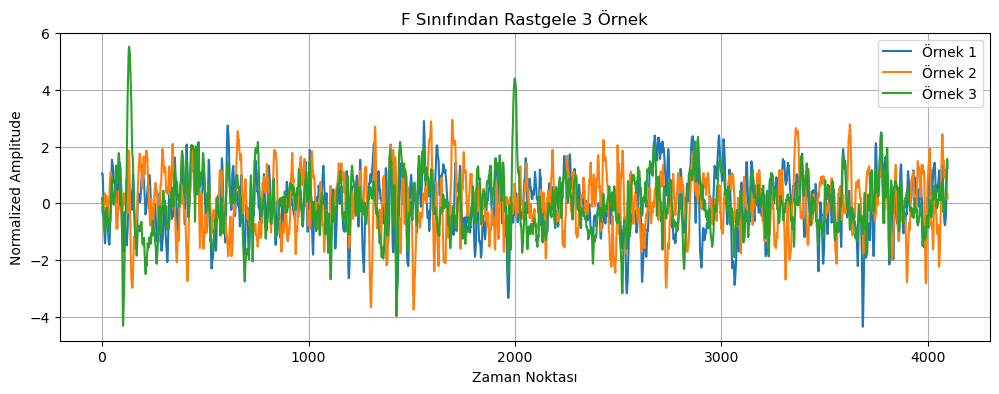

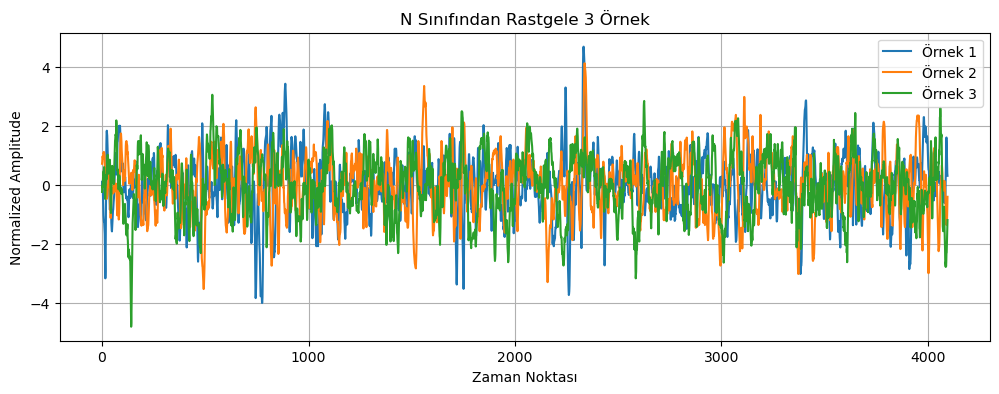

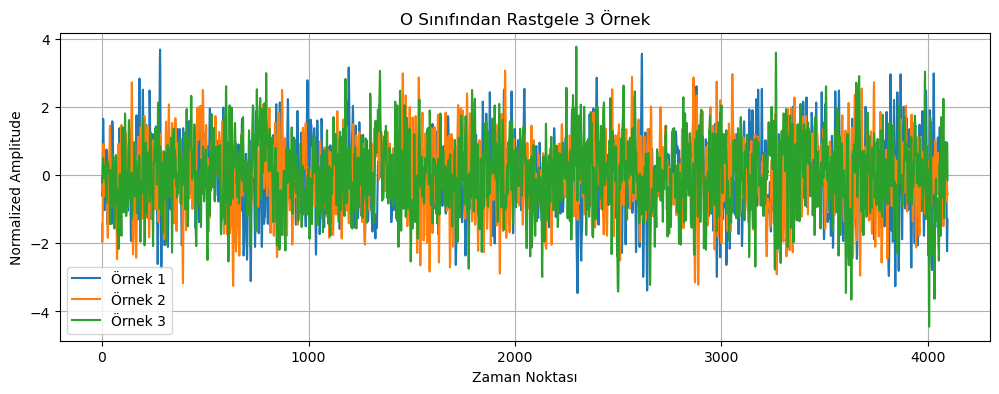

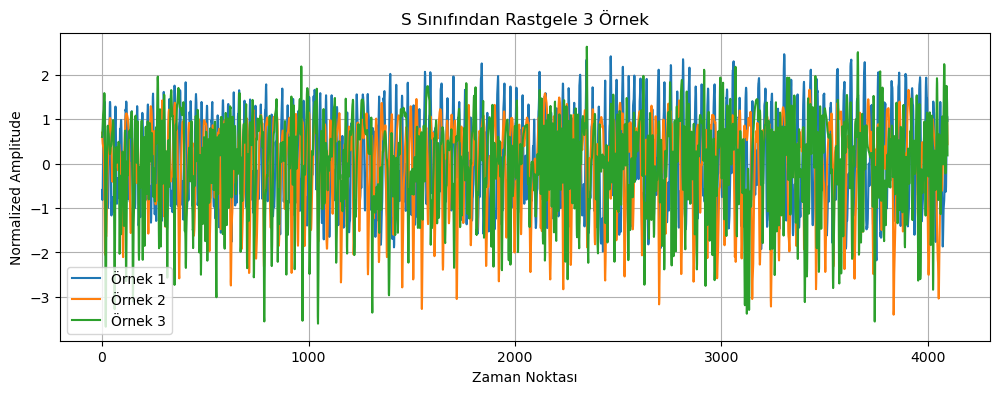

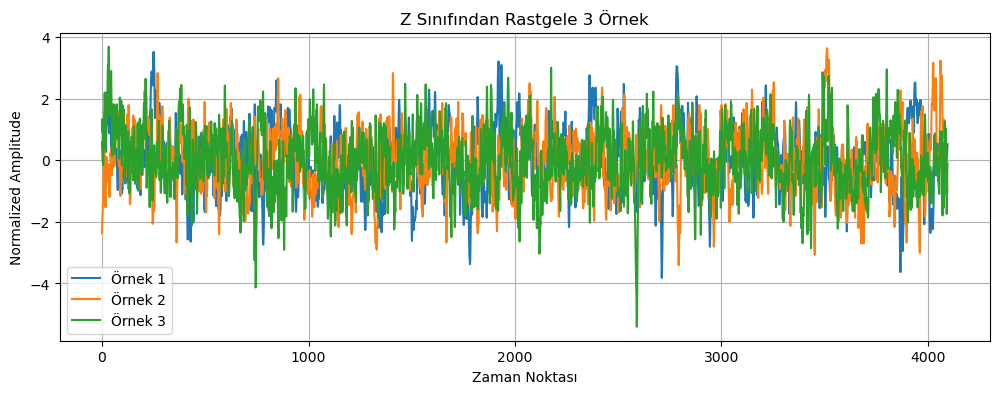

In [12]:
import random

def plot_few_samples(X, y, classes, n_samples=3):
    for cls_idx, cls_name in enumerate(classes):
        idxs = np.where(y==cls_idx)[0]
        chosen = random.sample(list(idxs), min(n_samples, len(idxs)))
        plt.figure(figsize=(12, 4))
        for i, idx in enumerate(chosen):
            plt.plot(X[idx].squeeze(), label=f"Örnek {i+1}")
        plt.title(f"{cls_name} Sınıfından Rastgele {n_samples} Örnek")
        plt.xlabel("Zaman Noktası")
        plt.ylabel("Normalized Amplitude")
        plt.legend()
        plt.grid(True)
        plt.show()

plot_few_samples(X, y, classes)


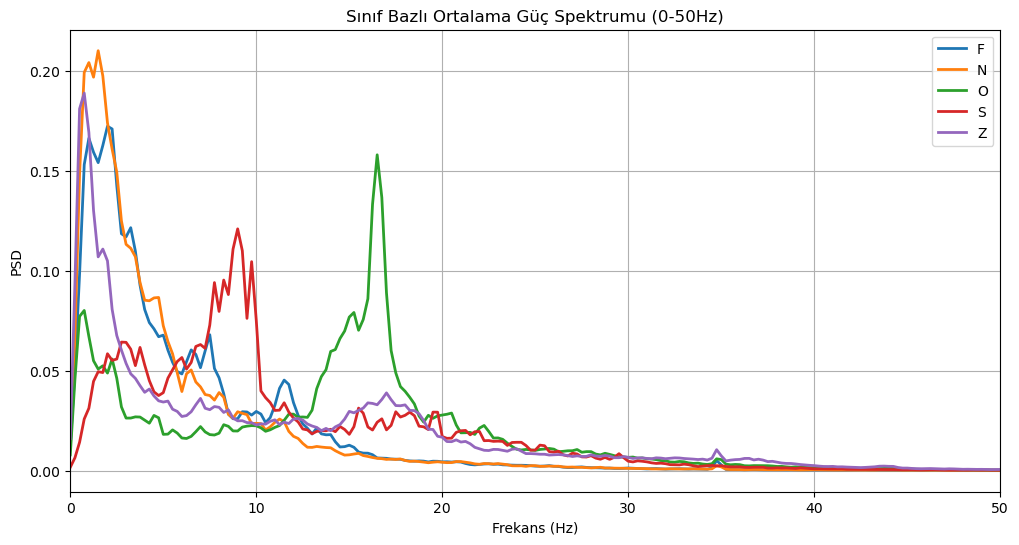

In [13]:
from scipy.signal import welch

def plot_class_psd_simple(X, y, classes, fs=256, max_freq=50):
    plt.figure(figsize=(12, 6))
    for cls_idx, cls_name in enumerate(classes):
        signals = X[y==cls_idx].squeeze()
        if len(signals) == 0:
            continue
        psd_list = []
        for sig in signals:
            f, Pxx = welch(sig, fs=fs, nperseg=1024)
            psd_list.append(Pxx)
        mean_psd = np.mean(psd_list, axis=0)
        plt.plot(f, mean_psd, label=f"{cls_name}", linewidth=2)
    plt.title("Sınıf Bazlı Ortalama Güç Spektrumu (0-50Hz)")
    plt.xlabel("Frekans (Hz)")
    plt.ylabel("PSD")
    plt.xlim(0, max_freq)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_class_psd_simple(X, y, classes)


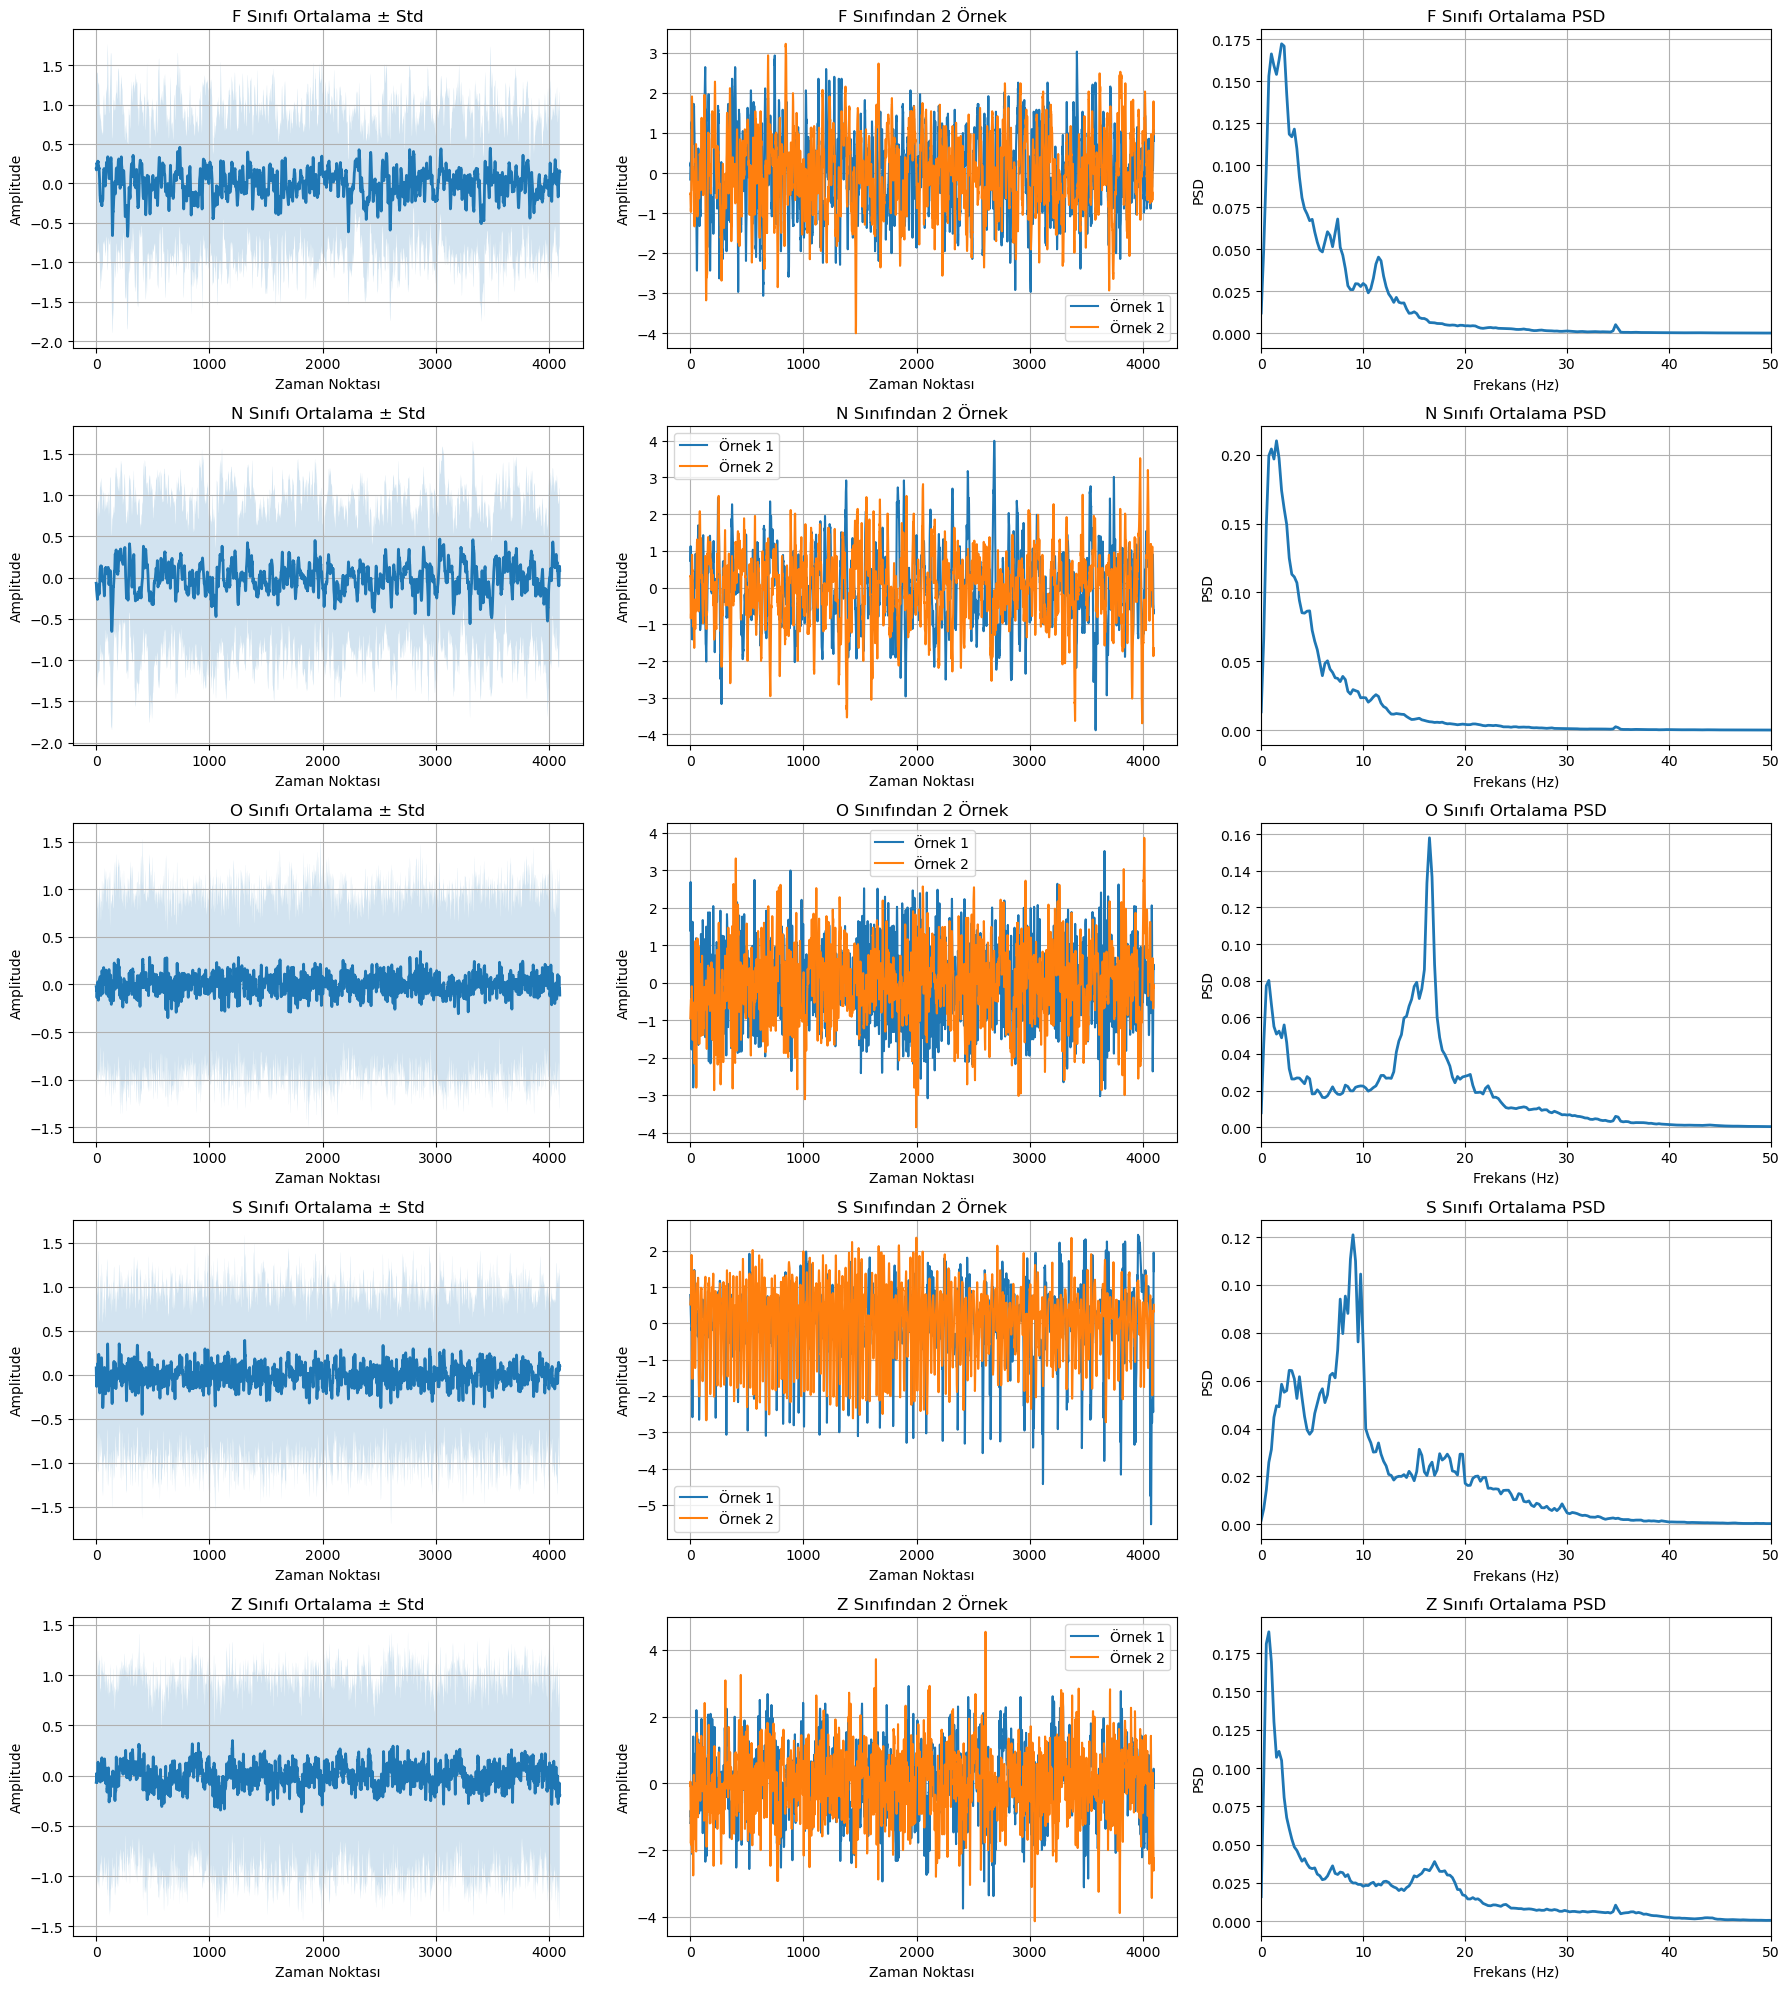

In [14]:
import matplotlib.pyplot as plt
from scipy.signal import welch
import numpy as np
import random

def plot_full_report(X, y, classes, fs=256, max_freq=50, n_samples=2):
    n_classes = len(classes)
    
    fig, axes = plt.subplots(n_classes, 3, figsize=(18, 4*n_classes))
    
    for cls_idx, cls_name in enumerate(classes):
        signals = X[y==cls_idx].squeeze()
        if len(signals) == 0:
            continue
        
        # 1️⃣ Ortalama ± Standart Sapma
        mean_signal = np.mean(signals, axis=0)
        std_signal = np.std(signals, axis=0)
        axes[cls_idx, 0].plot(mean_signal, label="Ortalama", linewidth=2)
        axes[cls_idx, 0].fill_between(range(len(mean_signal)), mean_signal-std_signal, mean_signal+std_signal, alpha=0.2)
        axes[cls_idx, 0].set_title(f"{cls_name} Sınıfı Ortalama ± Std")
        axes[cls_idx, 0].set_xlabel("Zaman Noktası")
        axes[cls_idx, 0].set_ylabel("Amplitude")
        axes[cls_idx, 0].grid(True)
        
        # 2️⃣ Rastgele Örnekler
        chosen = random.sample(list(range(signals.shape[0])), min(n_samples, signals.shape[0]))
        for i, idx in enumerate(chosen):
            axes[cls_idx, 1].plot(signals[idx], label=f"Örnek {i+1}")
        axes[cls_idx, 1].set_title(f"{cls_name} Sınıfından {n_samples} Örnek")
        axes[cls_idx, 1].set_xlabel("Zaman Noktası")
        axes[cls_idx, 1].set_ylabel("Amplitude")
        axes[cls_idx, 1].grid(True)
        axes[cls_idx, 1].legend()
        
        # 3️⃣ PSD
        psd_list = []
        for sig in signals:
            f, Pxx = welch(sig, fs=fs, nperseg=1024)
            psd_list.append(Pxx)
        mean_psd = np.mean(psd_list, axis=0)
        axes[cls_idx, 2].plot(f, mean_psd, linewidth=2)
        axes[cls_idx, 2].set_xlim(0, max_freq)
        axes[cls_idx, 2].set_title(f"{cls_name} Sınıfı Ortalama PSD")
        axes[cls_idx, 2].set_xlabel("Frekans (Hz)")
        axes[cls_idx, 2].set_ylabel("PSD")
        axes[cls_idx, 2].grid(True)
        
    plt.tight_layout()
    plt.show()

# Çalıştır
plot_full_report(X, y, classes, fs=256, max_freq=50, n_samples=2)


In [15]:
import matplotlib.pyplot as plt
from scipy.signal import welch
import numpy as np
import random

def plot_single_class(X, y, class_idx, class_name, fs=256, max_freq=50, n_samples=2):
    signals = X[y==class_idx].squeeze()
    if len(signals) == 0:
        print(f"{class_name} için veri bulunamadı.")
        return
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1️⃣ Ortalama ± Standart Sapma
    mean_signal = np.mean(signals, axis=0)
    std_signal = np.std(signals, axis=0)
    axes[0].plot(mean_signal, label="Ortalama", linewidth=2)
    axes[0].fill_between(range(len(mean_signal)), mean_signal-std_signal, mean_signal+std_signal, alpha=0.2)
    axes[0].set_title(f"{class_name} Sınıfı Ortalama ± Std")
    axes[0].set_xlabel("Zaman Noktası")
    axes[0].set_ylabel("Amplitude")
    axes[0].grid(True)
    
    # 2️⃣ Rastgele Örnekler
    chosen = random.sample(list(range(signals.shape[0])), min(n_samples, signals.shape[0]))
    for i, idx in enumerate(chosen):
        axes[1].plot(signals[idx], label=f"Örnek {i+1}")
    axes[1].set_title(f"{class_name} Sınıfından {n_samples} Örnek")
    axes[1].set_xlabel("Zaman Noktası")
    axes[1].set_ylabel("Amplitude")
    axes[1].grid(True)
    axes[1].legend()
    
    # 3️⃣ PSD
    psd_list = []
    for sig in signals:
        f, Pxx = welch(sig, fs=fs, nperseg=1024)
        psd_list.append(Pxx)
    mean_psd = np.mean(psd_list, axis=0)
    axes[2].plot(f, mean_psd, linewidth=2)
    axes[2].set_xlim(0, max_freq)
    axes[2].set_title(f"{class_name} Sınıfı Ortalama PSD")
    axes[2].set_xlabel("Frekans (Hz)")
    axes[2].set_ylabel("PSD")
    axes[2].grid(True)
    
    plt.tight_layout()
    plt.show()


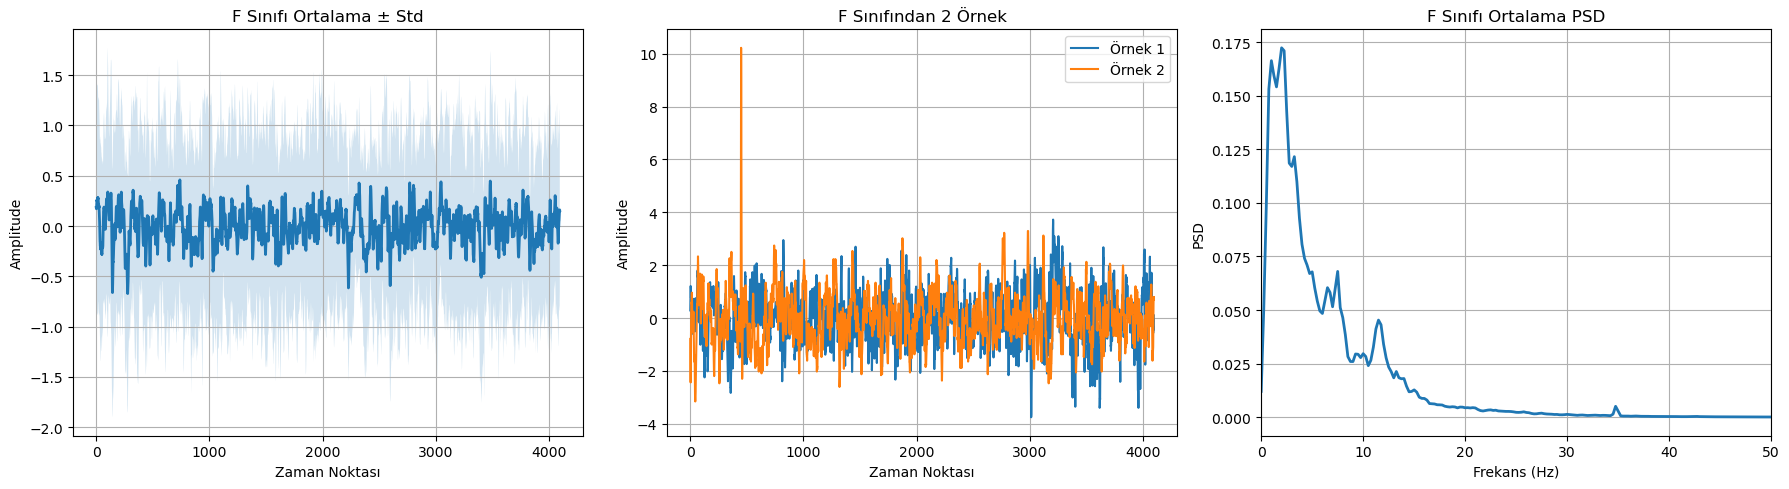

In [16]:
plot_single_class(X, y, class_idx=0, class_name="F")


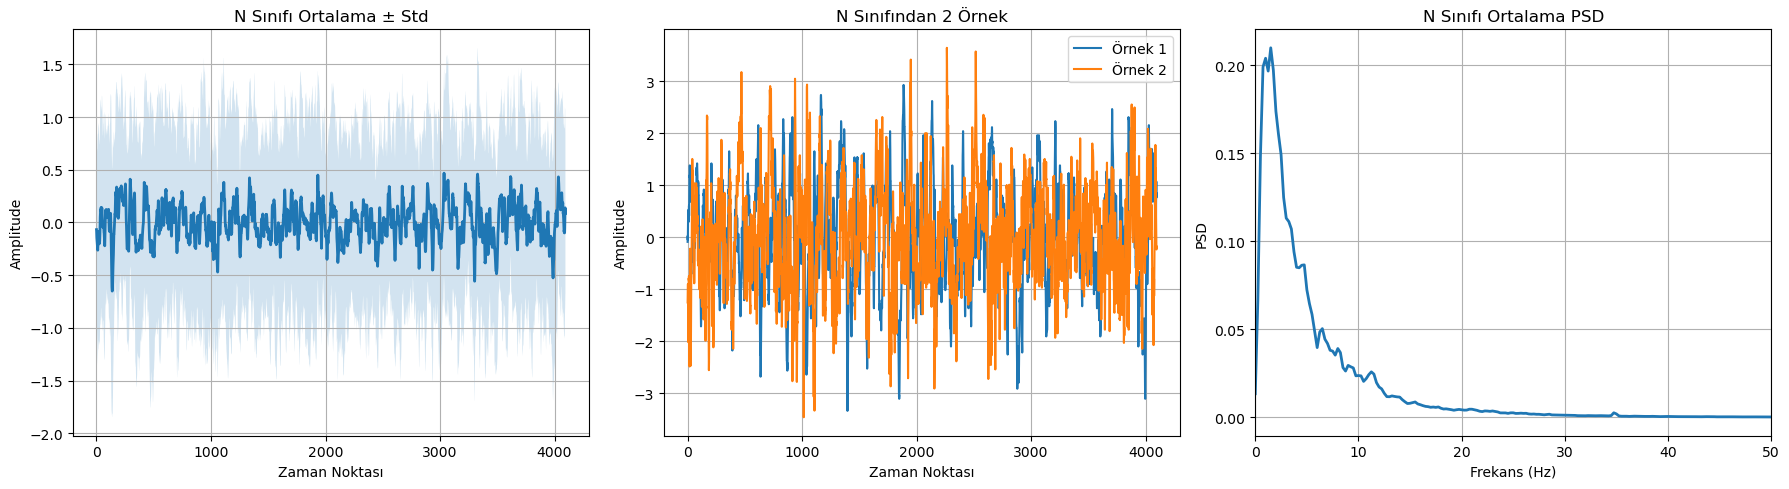

In [17]:
plot_single_class(X, y, class_idx=1, class_name="N")


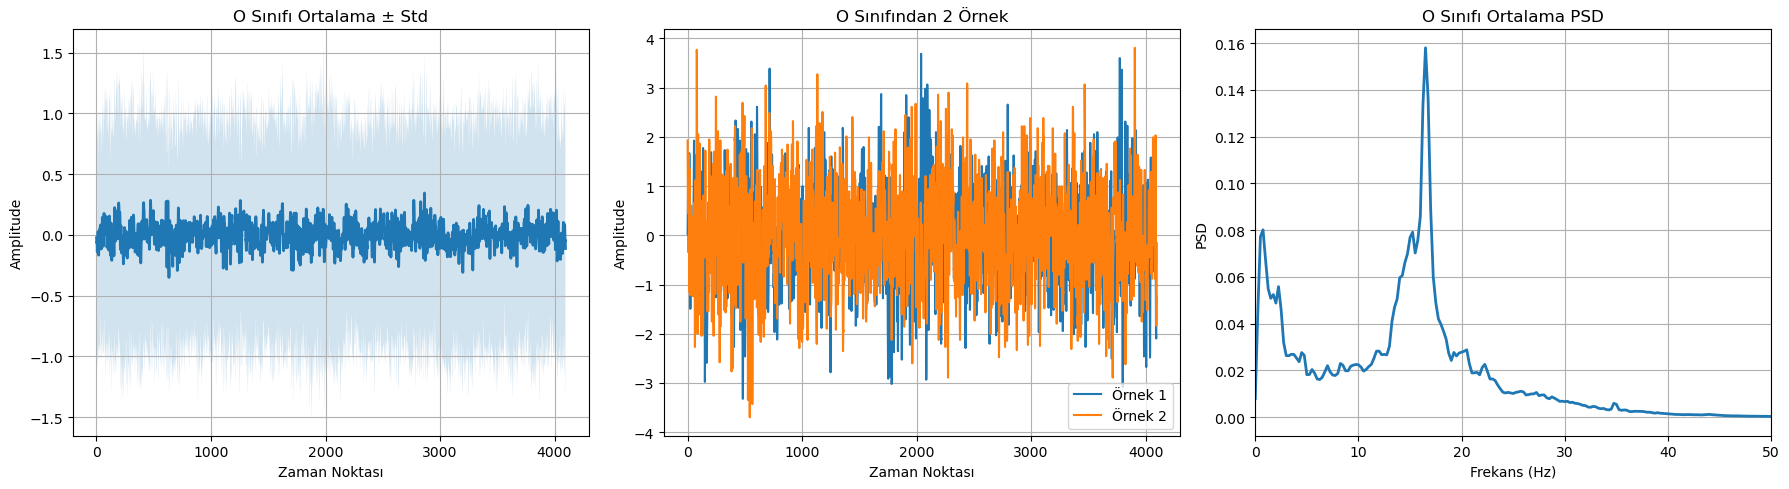

In [18]:
plot_single_class(X, y, class_idx=2, class_name="O")


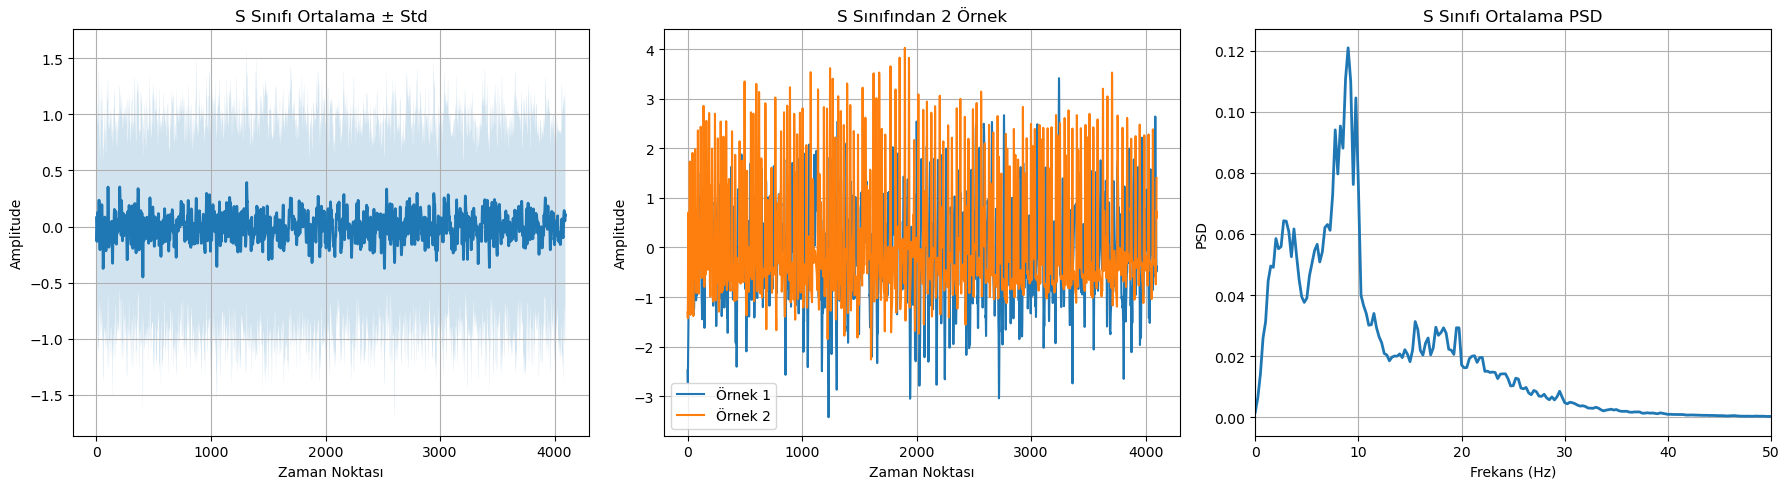

In [19]:
plot_single_class(X, y, class_idx=3, class_name="S")


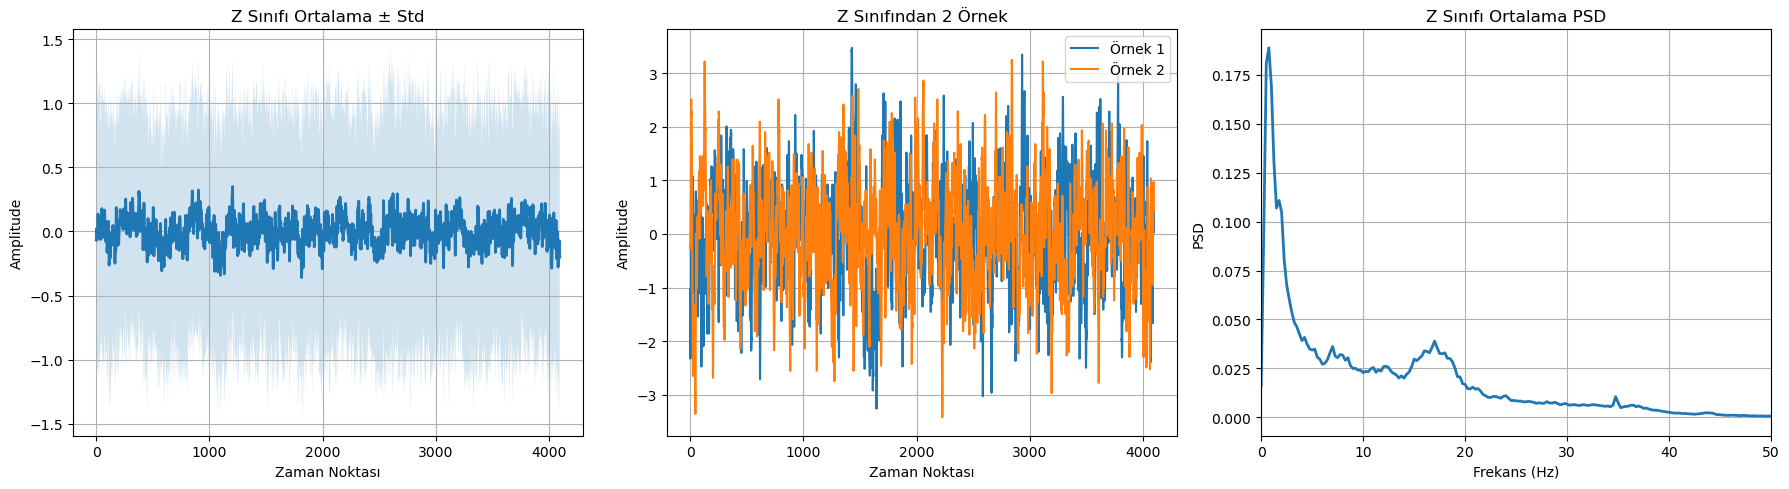

In [20]:
plot_single_class(X, y, class_idx=4, class_name="Z")

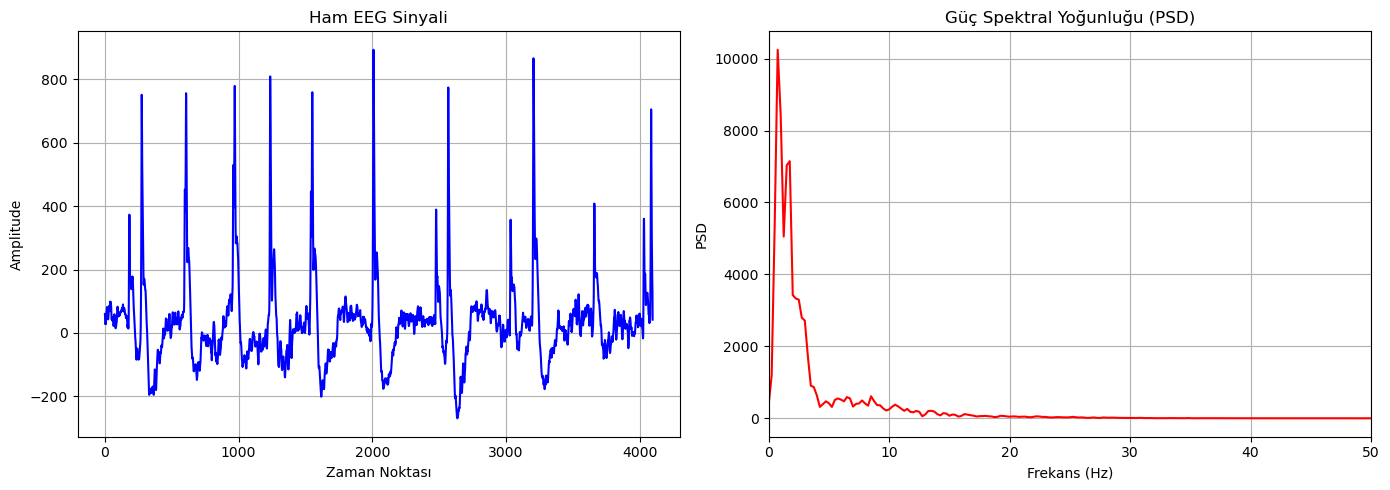

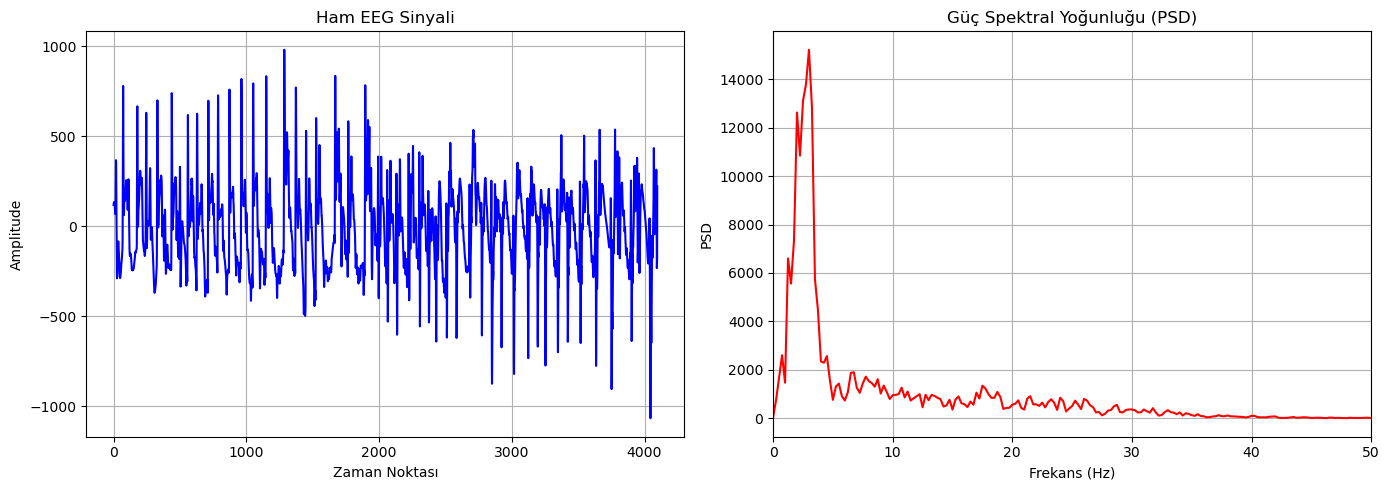

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
import tkinter as tk
from tkinter import filedialog, messagebox

def plot_single_eeg(file_path, fs=256, max_freq=50):
    """Seçilen tek EEG dosyası için grafik çizer."""
    try:
        # Dosyadan veriyi oku
        signal = np.loadtxt(file_path)
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # 1️⃣ Zaman domeni grafiği
        axes[0].plot(signal, color="b")
        axes[0].set_title("Ham EEG Sinyali")
        axes[0].set_xlabel("Zaman Noktası")
        axes[0].set_ylabel("Amplitude")
        axes[0].grid(True)
        
        # 2️⃣ PSD grafiği
        f, Pxx = welch(signal, fs=fs, nperseg=1024)
        axes[1].plot(f, Pxx, color="r")
        axes[1].set_xlim(0, max_freq)
        axes[1].set_title("Güç Spektral Yoğunluğu (PSD)")
        axes[1].set_xlabel("Frekans (Hz)")
        axes[1].set_ylabel("PSD")
        axes[1].grid(True)
        
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        messagebox.showerror("Hata", f"Dosya okunamadı: {e}")

def select_file():
    """Dosya seçim penceresi açar."""
    file_path = filedialog.askopenfilename(
        title="EEG Dosyası Seç",
        filetypes=[("Text Files", "*.txt"), ("All Files", "*.*")]
    )
    if file_path:
        plot_single_eeg(file_path)

# Ana GUI penceresi
root = tk.Tk()
root.title("EEG Görselleştirme")

label = tk.Label(root, text="Bir EEG .txt dosyası seçin:", font=("Arial", 12))
label.pack(pady=10)

btn = tk.Button(root, text="Dosya Seç", command=select_file, font=("Arial", 12), bg="#4CAF50", fg="white")
btn.pack(pady=20)

root.geometry("300x150")
root.mainloop()